<a href="https://colab.research.google.com/github/Naomy-Yailin/SIS420/blob/main/Laboratorio7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**APRENDIZAJE NO SUPERVISADO**

**Clustering**: Es agrupar datos que se parecen entre sí (como separar piezas de Lego por color). Se usa para segmentar clientes, buscar imágenes o detectar errores.

**K-Means**: Es el método más rápido para hacer estos grupos. Funciona buscando puntos centrales (centroides).

Se crearon datos artificiales con centros muy separados (entre 1 y 20) para que se note claramente cómo el algoritmo identifica y separa cada grupo.

**PASOS:**

GENERADOR DE DATASET ALEATORIO MEJORADO

* n_clusters: número aleatorio
entre 1 y 20.
* Los centroides se separan usando una cuadrícula con jitter para garantizar gran distancia visual entre grupos.
* std pequeño para que los clusters sean compactos y bien diferenciados.

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

# Número aleatorio de clusters entre 1 y 20
n_clusters = np.random.randint(1, 21)
print(f" Número de clusters generado aleatoriamente: {n_clusters}")

# Crear centroides bien separados usando una cuadrícula base
# Separación mínima de 10 unidades entre centroides
SEPARATION = 12.0
cols = int(np.ceil(np.sqrt(n_clusters)))
blob_centers = []
for i in range(n_clusters):
    row = i // cols
    col = i % cols
    # Pequeño jitter para que no queden en rejilla perfecta
    jitter = np.random.uniform(-1.5, 1.5, size=2)
    center = np.array([col * SEPARATION, row * SEPARATION]) + jitter
    blob_centers.append(center)

blob_centers = np.array(blob_centers)

# Desviación estándar pequeña para clusters compactos y bien separados
blob_std = np.full(n_clusters, 1.2)

# Generar el dataset
X, y = make_blobs(
    n_samples=2000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=42
)

print(f"Dataset generado: {X.shape[0]} muestras, {n_clusters} clusters")
print(f"Rango X: [{X[:,0].min():.1f}, {X[:,0].max():.1f}]")
print(f"Rango Y: [{X[:,1].min():.1f}, {X[:,1].max():.1f}]")

 Número de clusters generado aleatoriamente: 7
Dataset generado: 2000 muestras, 7 clusters
Rango X: [-3.7, 26.6]
Rango Y: [-4.7, 25.5]


VISUALIZACIÓN INICIAL DE LOS DATOS


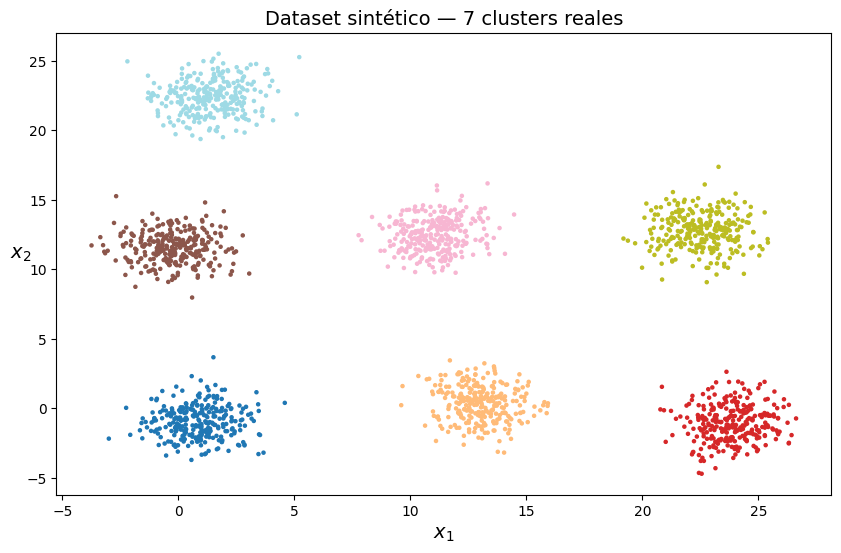

In [55]:

def plot_clusters(X, y=None):
    """Visualiza los puntos del dataset. Si se pasa y, colorea por cluster."""
    plt.scatter(X[:, 0], X[:, 1], c=y, s=5, cmap='tab20')
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(10, 6))
plot_clusters(X, y)
plt.title(f"Dataset sintético — {n_clusters} clusters reales", fontsize=14)
plt.show()

Entrenamos KMeans con el número exacto de clusters generados


In [56]:
from sklearn.cluster import KMeans

k = n_clusters
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

print(f" KMeans entrenado con k={k}")
print(f" Centroides encontrados:\n{kmeans.cluster_centers_}")

 KMeans entrenado con k=7
 Centroides encontrados:
[[23.85670342 -1.07807564]
 [11.04710549 12.45105182]
 [13.0051966   0.37116465]
 [ 1.37354649 22.39141074]
 [22.52424985 12.76313859]
 [-0.22216751 11.55896889]
 [ 0.86635613 -0.96439301]]


FUNCIONES AUXILIARES DE VISUALIZACIÓN

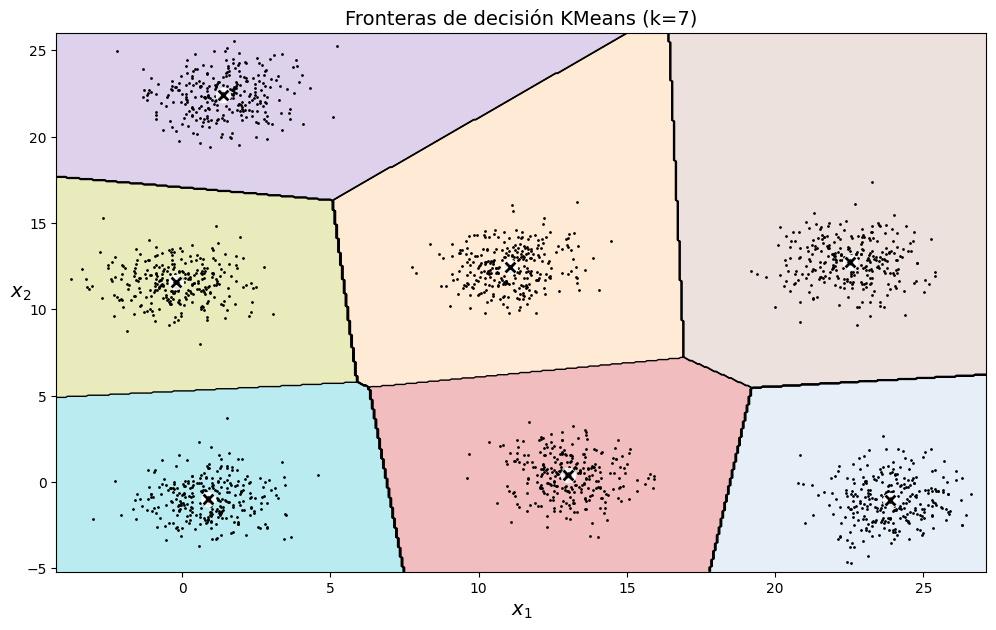

In [57]:

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    """Dibuja los centroides con un círculo y una cruz."""
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=500, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    """
    Dibuja las fronteras de decisión del modelo de clustering.
    Resolución reducida a 500 para datasets con muchos clusters (más rápido).
    """
    mins = X.min(axis=0) - 0.5
    maxs = X.max(axis=0) + 0.5
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                 cmap="tab20", alpha=0.3)
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

# Visualizar fronteras de decisión del KMeans entrenado
plt.figure(figsize=(12, 7))
plot_decision_boundaries(kmeans, X)
plt.title(f"Fronteras de decisión KMeans (k={k})", fontsize=14)
plt.show()

**Soft clustering:** distancia de nuevas muestras a cada centroide


In [58]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
print("Predicción hard (cluster asignado):", kmeans.predict(X_new))
print("\n Distancias soft a cada centroide:")
print(kmeans.transform(X_new))

Predicción hard (cluster asignado): [6 6 6 6]

 Distancias soft a cada centroide:
[[24.05445588 15.20733454 13.10680141 20.4376188  24.96371333  9.56155032
   3.08839746]
 [21.08261433 13.19016266 10.13691588 20.45617225 22.2944272  10.08743028
   3.65240497]
 [27.16455815 16.93055088 16.21965146 19.87849893 27.32775522  8.99846107
   5.53760975]
 [27.09400568 17.2146625  16.14615304 20.36654439 27.51034976  9.47529792
   5.19140913]]


Visualización de las iteraciones del algoritmo KMeans


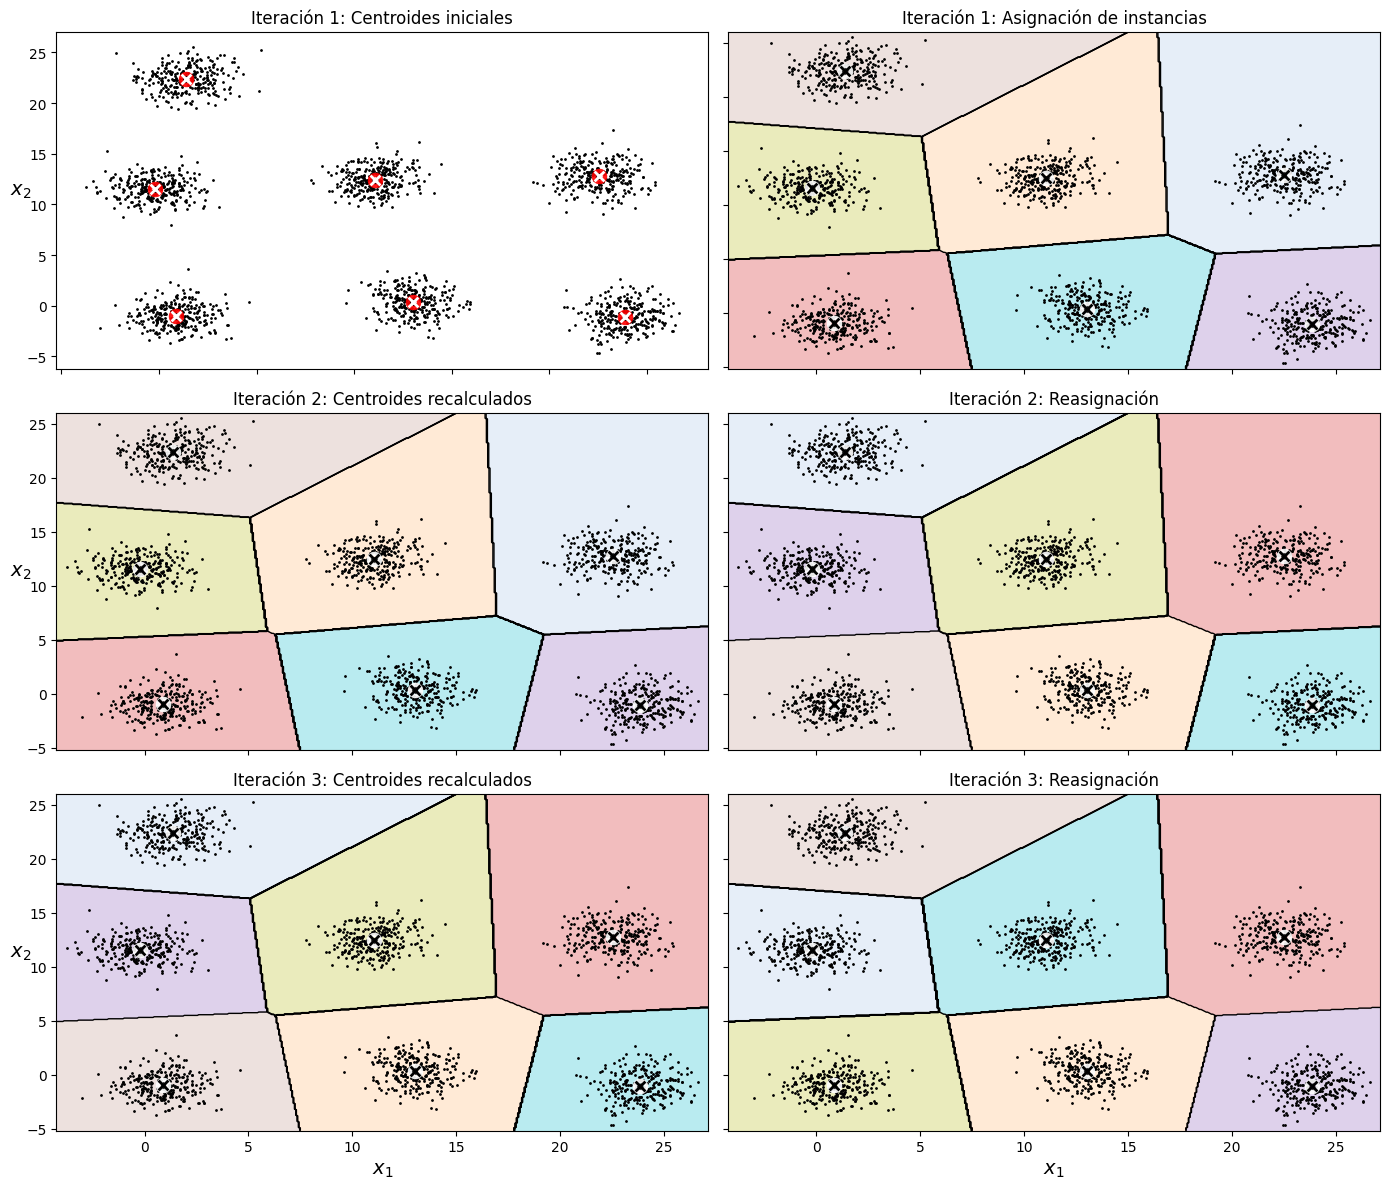

In [59]:
kmeans_iter1 = KMeans(n_clusters=k, init='k-means++', n_init=1,
                      algorithm='elkan', max_iter=1, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init='k-means++', n_init=1,
                      algorithm='elkan', max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init='k-means++', n_init=1,
                      algorithm='elkan', max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Iteración 1: Centroides iniciales", fontsize=12)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Iteración 1: Asignación de instancias", fontsize=12)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)
plt.title("Iteración 2: Centroides recalculados", fontsize=12)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)
plt.title("Iteración 2: Reasignación", fontsize=12)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)
plt.title("Iteración 3: Centroides recalculados", fontsize=12)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)
plt.title("Iteración 3: Reasignación", fontsize=12)

plt.tight_layout()
plt.show()

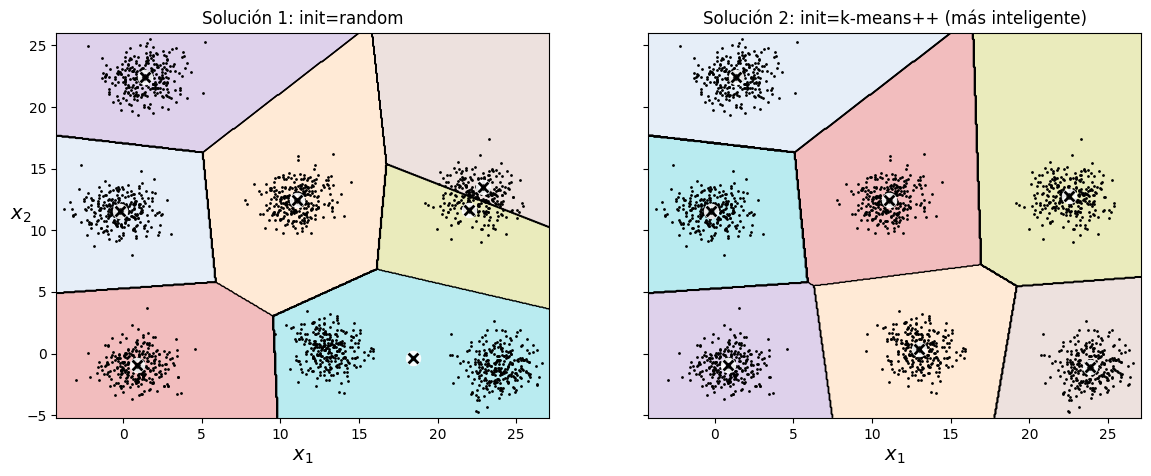

In [60]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    """Compara dos configuraciones de KMeans lado a lado."""
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(14, 5))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=12)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=12)

kmeans_rnd_init1 = KMeans(n_clusters=k, init='random', n_init=1,
                          algorithm='elkan', random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=k, init='k-means++', n_init=1,
                          algorithm='lloyd', random_state=19)

plot_clusterer_comparison(
    kmeans_rnd_init1, kmeans_rnd_init2, X,
    "Solución 1: init=random",
    "Solución 2: init=k-means++ (más inteligente)"
)
plt.show()

Para minimizar el impacto de la inicialización: probar n_init=10 inicializaciones


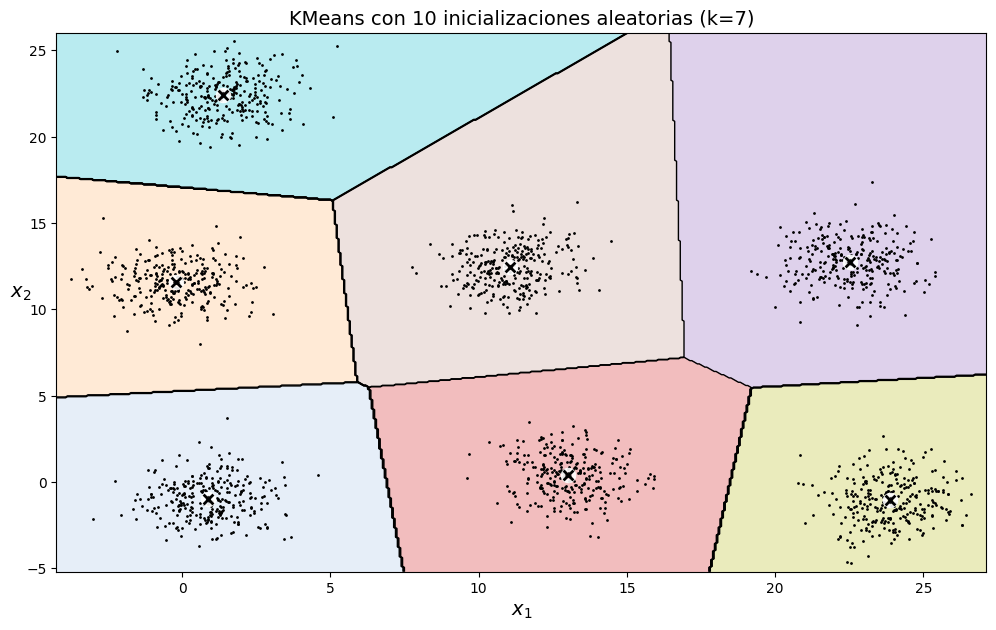

In [61]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init='random', n_init=10,
                              algorithm='elkan', random_state=11)
kmeans_rnd_10_inits.fit(X)

plt.figure(figsize=(12, 7))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.title(f"KMeans con 10 inicializaciones aleatorias (k={k})", fontsize=14)
plt.show()

# MÉTODO DEL CODO (Elbow Method)
 Evaluamos k desde 1 hasta min(20, n_clusters+5)



Evaluando k de 1 a 12...


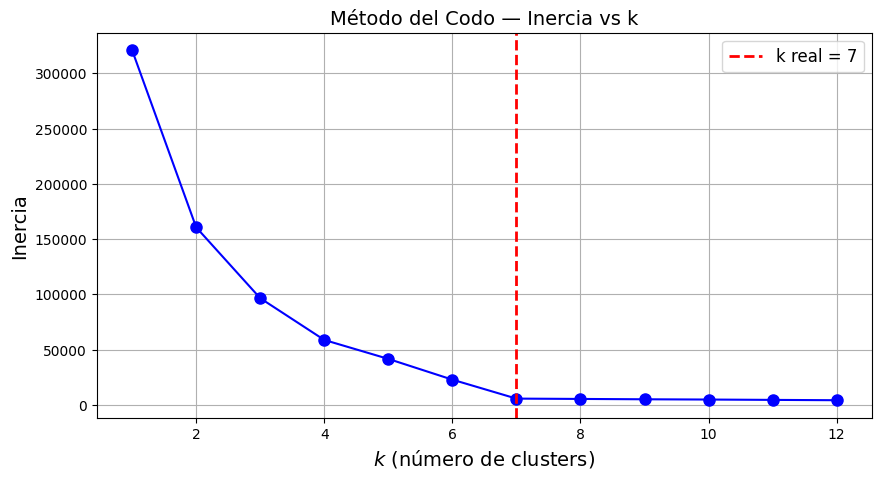


 El codo debería estar cerca de k=7


In [62]:
max_k = min(20, n_clusters + 5)
print(f"Evaluando k de 1 a {max_k}...")

kmeans_per_k = [
    KMeans(n_clusters=k_val, random_state=42, n_init=5).fit(X)
    for k_val in range(1, max_k + 1)
]

inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_k + 1), inertias, 'bo-', markersize=8)
plt.axvline(x=n_clusters, color='red', linestyle='--', linewidth=2,
            label=f'k real = {n_clusters}')
plt.xlabel("$k$ (número de clusters)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo — Inercia vs k", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print(f"\n El codo debería estar cerca de k={n_clusters}")

Score para el k correcto


In [63]:
from sklearn.metrics import silhouette_score

score_real_k = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score para k={n_clusters} (k real): {score_real_k:.4f}")

Silhouette Score para k=7 (k real): 0.8047


**SILHOUETTE SCORE PARA DISTINTOS VALORES DE k**
 Calculamos silhouette para k >= 2 (no tiene sentido con 1 solo cluster)

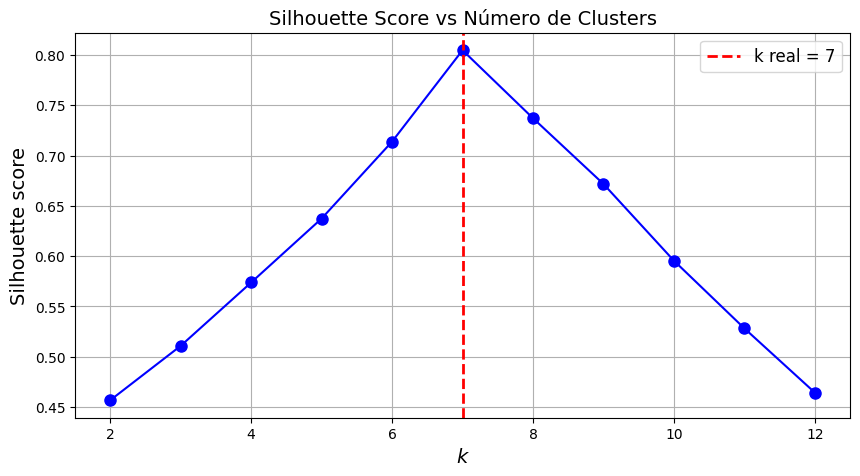


 Mejor k según Silhouette Score: 7
 k real generado: 7


In [64]:
silhouette_scores = [
    silhouette_score(X, model.labels_)
    for model in kmeans_per_k[1:]  # saltamos k=1
]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(ks, silhouette_scores, 'bo-', markersize=8)
plt.axvline(x=n_clusters, color='red', linestyle='--', linewidth=2,
            label=f'k real = {n_clusters}')
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

best_k = ks[np.argmax(silhouette_scores)]
print(f"\n Mejor k según Silhouette Score: {best_k}")
print(f" k real generado: {n_clusters}")


**DIAGRAMAS DE SILUETA PARA DISTINTOS k**
Visualizamos los coeficientes de silueta de cada muestra por cluster



 Visualizando diagramas de silueta para k = [5, 6, 7, 8]


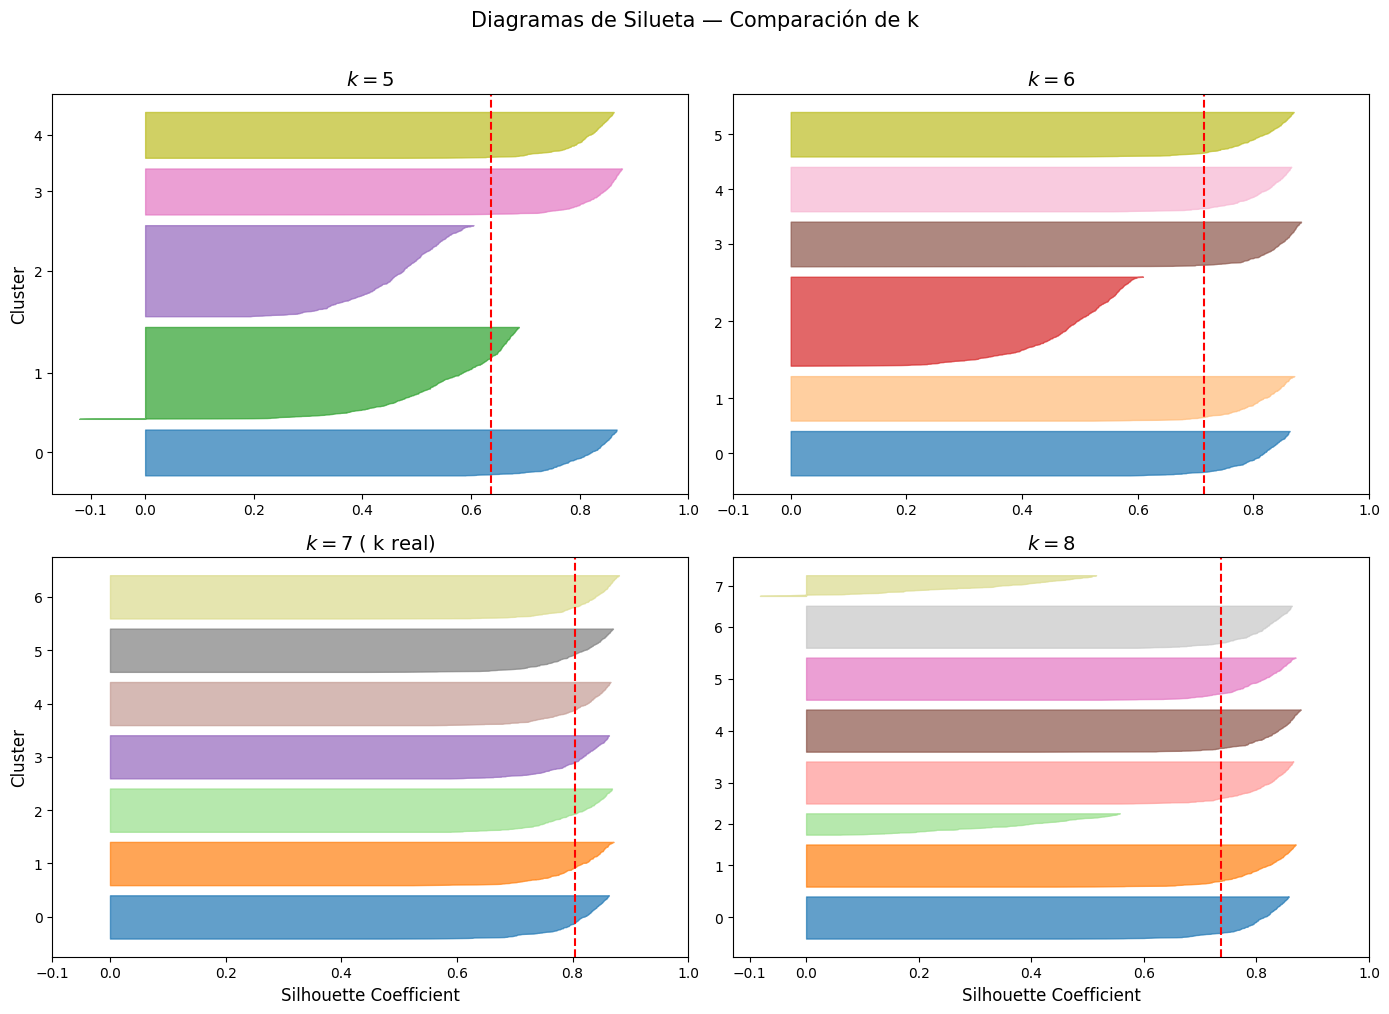

In [65]:

from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

# Elegimos 4 valores de k para visualizar
# Siempre incluimos el k real y sus vecinos
candidates = sorted(set([
    max(2, n_clusters - 2),
    max(2, n_clusters - 1),
    n_clusters,
    min(max_k, n_clusters + 1)
]))
# Nos quedamos con máximo 4
candidates = candidates[:4]
print(f" Visualizando diagramas de silueta para k = {candidates}")

plt.figure(figsize=(14, 10))

for plot_idx, k_val in enumerate(candidates):
    plt.subplot(2, 2, plot_idx + 1)

    model = kmeans_per_k[k_val - 1]
    y_pred_sil = model.labels_
    silhouette_coefficients = silhouette_samples(X, y_pred_sil)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k_val):
        coeffs = silhouette_coefficients[y_pred_sil == i]
        coeffs.sort()
        color = mpl.cm.tab20(i / k_val)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k_val)))
    if plot_idx in (0, 2):
        plt.ylabel("Cluster", fontsize=12)
    if plot_idx in (2, 3):
        plt.xlabel("Silhouette Coefficient", fontsize=12)

    mean_score = silhouette_scores[k_val - 2] if k_val >= 2 else 0
    plt.axvline(x=mean_score, color='red', linestyle='--', label=f'Media={mean_score:.3f}')
    label_real = " ( k real)" if k_val == n_clusters else ""
    plt.title(f"$k={k_val}${label_real}", fontsize=14)
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle("Diagramas de Silueta — Comparación de k", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

INSTALACIÓN DE DEPENDENCIAS
**texto en negrita**

In [66]:
!pip install roboflow opencv-python-headless scikit-image tqdm -q

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


DATA_DIR = "/content/drive/MyDrive/datasets/Hyper-Kvasir.v1-416x416-no-aug.folder"

def cargar_desde_drive(base_path):
    features = []
    labels = []
    img_size = (64, 64)

    # rglob buscará dentro de 'train', 'test' y 'valid' automáticamente
    path_obj = Path(base_path)
    image_paths = list(path_obj.rglob("*.jpg")) + list(path_obj.rglob("*.png"))

    if len(image_paths) == 0:
        print(" No se encontraron imágenes. Verifica que DATA_DIR sea correcta.")
        return None, None

    print(f" Imágenes encontradas en Drive: {len(image_paths)}")

    for path in tqdm(image_paths, desc="Extrayendo HOG"):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        img = cv2.resize(img, img_size)

        # Descriptor HOG
        feat = hog(img, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), feature_vector=True)

        features.append(feat)
        labels.append(path.parent.name) # Nombre de la subcarpeta (ej: 'polyps')

    return np.array(features), np.array(labels)

# --- EJECUCIÓN ---
X, y_raw = cargar_desde_drive(DATA_DIR)

if X is not None:
    # Codificar etiquetas a números
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    # Escalado y Split
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.25, random_state=42
    )

    print(f"\n ¡Éxito! Datos listos para el modelo.")
    print(f"Dimensiones de X_train: {X_train.shape}")

 Imágenes encontradas en Drive: 5566


Extrayendo HOG: 100%|██████████| 5566/5566 [01:30<00:00, 61.42it/s]



 ¡Éxito! Datos listos para el modelo.
Dimensiones de X_train: (4174, 1764)


#Semi-Supervisado

El aprendizaje semi-supervisado(Semi-supervised Learning) comprende el conjunto de técnicas que nos permiten entrenar modelos con datasets parcialmente etiquetados

Aplicamos la misma técnica del cuadernillo original:

1. Entrenar KMeans con $k=50$ clusters
2. Encontrar la imagen más representativa de cada cluster (la más cercana al centroide)
3. Etiquetar solo esas 50 imágenes
4. Entrenar un clasificador con esas pocas muestras representativas
5. Propagar las etiquetas al resto del dataset

In [69]:
from sklearn.cluster import KMeans

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

print(X_digits_dist.shape)
print(X_digits_dist)

idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

print(X_representative_digits.shape)
print(X_representative_digits)


(4174, 50)
[[57.85461224 47.97399151 53.35013005 ... 52.99209886 53.77168131
  50.77257809]
 [55.34927237 47.6109764  53.64650798 ... 42.91256113 45.93475098
  48.42249358]
 [48.97824435 43.71735727 46.40744531 ... 42.7121297  41.68223328
  46.93529585]
 ...
 [55.49533178 42.83662816 50.2131399  ... 44.22852388 42.37566041
  41.11618162]
 [53.34569958 42.40085947 49.97626359 ... 42.77982317 42.51300414
  40.01680225]
 [55.12983369 44.19123665 48.66380946 ... 42.07724887 40.65725235
  47.1592845 ]]
(50, 1764)
[[ 1.63579623 -0.07127486 -0.52795058 ... -0.34667422 -0.38312718
  -0.56723322]
 [ 0.46498118  1.04204069  0.4852074  ... -0.19633947 -0.38312718
  -0.56723322]
 [ 1.18782054  0.00218941 -1.33101602 ... -0.34667422 -0.38312718
   0.52865526]
 ...
 [-0.67646953 -0.08164154 -0.30856528 ... -0.34667422 -0.28882033
   0.39336724]
 [-0.51500289  0.79661918 -0.23794682 ...  0.05922828  0.63083471
   0.39683373]
 [ 1.18856132  0.85074619  0.73095829 ... -0.34667422 -0.29853072
  -0.24617

# Visualización de las imágenes más representativas

A continuación se muestran las **50 imágenes más representativas** (una por cluster),
exactamente igual que en el cuadernillo original pero con imágenes reales de Hyper-Kvasir.
Estas son las que un médico/experto etiquetaría manualmente.



**GRÁFICA 1:** Grid 5x10 de imágenes representativas
(misma estructura que el cuadernillo original)


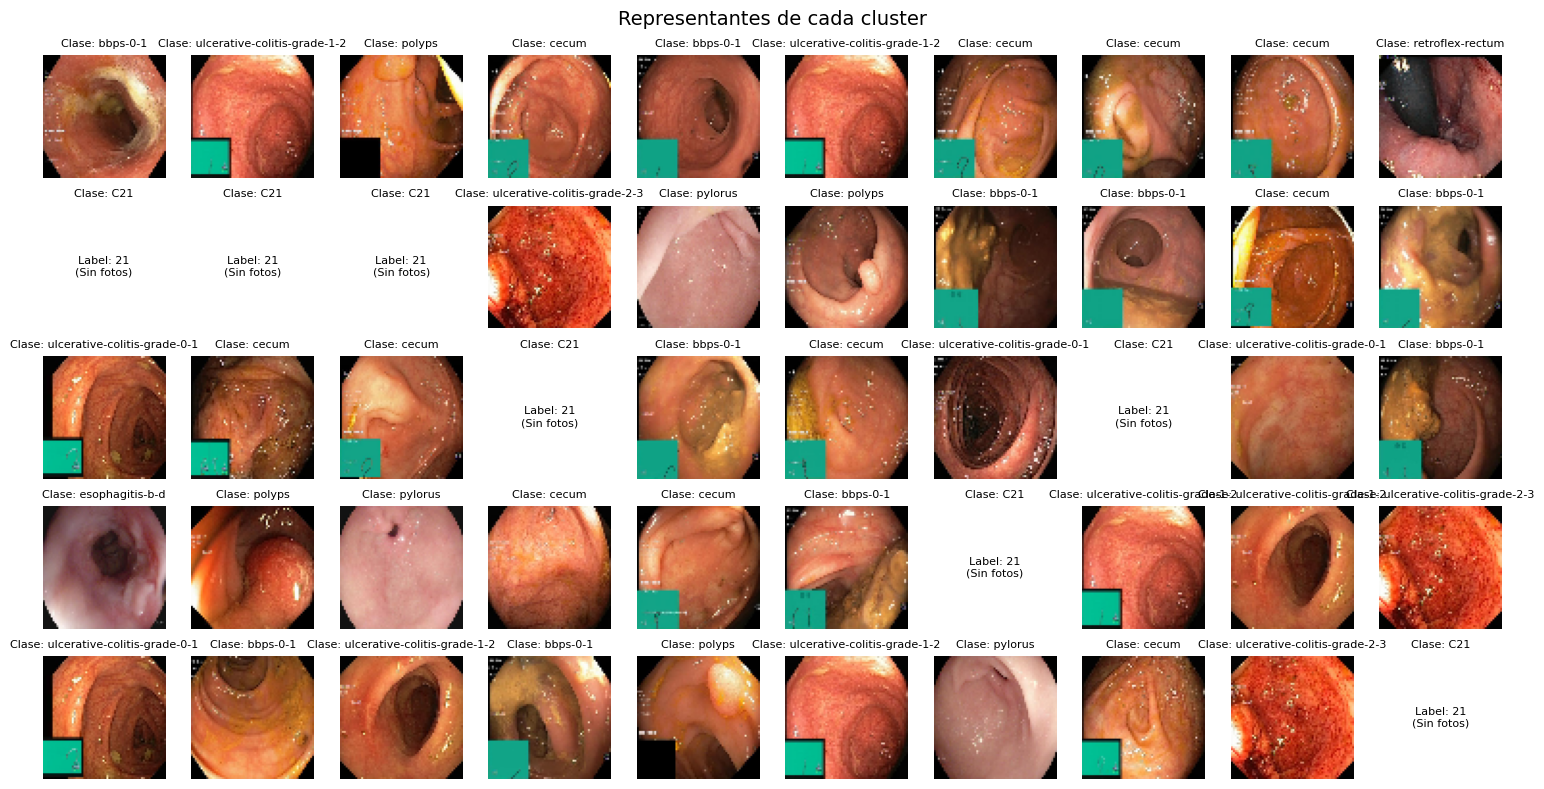

In [70]:
import os

# Define las rutas según tu estructura de carpetas
TRAIN_DIR = '/content/drive/MyDrive/datasets/Hyper-Kvasir.v1-416x416-no-aug.folder/test'
VALID_DIR = '/content/drive/MyDrive/datasets/Hyper-Kvasir.v1-416x416-no-aug.folder/valid'
TEST_DIR  = '/content/drive/MyDrive/datasets/Hyper-Kvasir.v1-416x416-no-aug.folder/test'

EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
CLASES = sorted(os.listdir(TRAIN_DIR))
cls_archivos = {}

for cls in CLASES:
    archivos_cls = []
    for split in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
        p = os.path.join(split, cls)
        if os.path.exists(p):
            # Filtramos archivos por extensión
            archivos_cls += [os.path.join(p, f)
                             for f in os.listdir(p)
                             if f.lower().endswith(EXTS)]
    cls_archivos[cls] = archivos_cls

# 3. Visualización de imágenes representativas
y_representative_digits = y_train[idxs]

plt.figure(figsize=(15, 8))
for index in range(k):
    label = y_representative_digits[index]

    if label < len(CLASES):
        clase = CLASES[label]
        archivos = cls_archivos.get(clase, [])
    else:
        clase = f"C{label}"
        archivos = []

    plt.subplot(5, 10, index + 1)
    if archivos:
        img_path = archivos[index % len(archivos)]
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (64, 64))
            plt.imshow(img)
    else:
        # Si no hay imagen o la clase no existe, ponemos un texto
        plt.text(0.5, 0.5, f'Label: {label}\n(Sin fotos)',
                 ha='center', va='center', fontsize=8)

    plt.title(f"Clase: {clase}", fontsize=8)
    plt.axis('off')

plt.suptitle("Representantes de cada cluster", fontsize=14)
plt.tight_layout()
plt.show()


ETIQUETAR REPRESENTATIVAS

In [71]:
y_representative_digits = y_train[idxs]

from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
score_rep = log_reg2.score(X_test, y_test)
print(f"Accuracy con {k} representativas: {score_rep:.4f} ({score_rep*100:.2f}%)")

log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:50], y_train[:50])
score_rand = log_reg.score(X_test, y_test)
print(f"Accuracy con 50 aleatorias: {score_rand:.4f} ({score_rand*100:.2f}%)")

print(f"\\n→ Mejora: +{(score_rep - score_rand)*100:.2f}% usando representativas")


'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.


CPU times: user 530 ms, sys: 0 ns, total: 530 ms
Wall time: 517 ms
Accuracy con 50 representativas: 0.3693 (36.93%)


'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.


CPU times: user 631 ms, sys: 0 ns, total: 631 ms
Wall time: 482 ms
Accuracy con 50 aleatorias: 0.3154 (31.54%)
\n→ Mejora: +5.39% usando representativas


PROPAGACIÓN

Asignamos a todas las muestras de un cluster la etiqueta de su representante


In [72]:
y_train_propagated = np.empty(len(X_train), dtype=y_train.dtype)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
score_prop = log_reg3.score(X_test, y_test)
print(f"Accuracy con 1000 muestras propagadas: {score_prop:.4f} ({score_prop*100:.2f}%)")


'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.


CPU times: user 5.56 s, sys: 0 ns, total: 5.56 s
Wall time: 2.99 s
Accuracy con 1000 muestras propagadas: 0.4210 (42.10%)


 PLOT COMPARATIVA SEMI

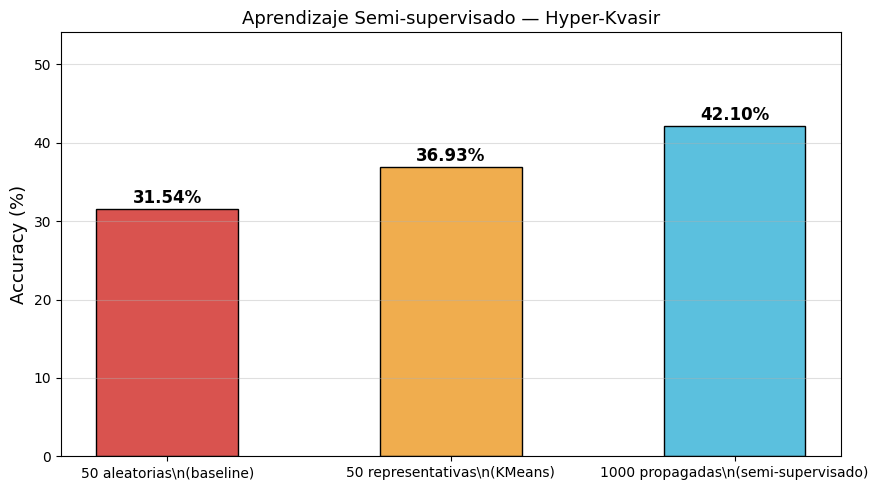

In [73]:
 # GRÁFICA 2: Comparación semi-supervisado

etiquetas = [
    f"50 aleatorias\\n(baseline)",
    f"50 representativas\\n(KMeans)",
    f"1000 propagadas\\n(semi-supervisado)"
]
scores_semi = [score_rand, score_rep, score_prop]
colores_semi = ['#d9534f', '#f0ad4e', '#5bc0de']

plt.figure(figsize=(9, 5))
bars = plt.bar(etiquetas, [s * 100 for s in scores_semi],
               color=colores_semi, edgecolor='black', width=0.5)
for bar, s in zip(bars, scores_semi):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{s*100:.2f}%", ha='center', va='bottom',
             fontsize=12, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("Aprendizaje Semi-supervisado — Hyper-Kvasir", fontsize=13)
plt.ylim(0, min(110, max(s*100 for s in scores_semi) + 12))
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()




# APRENDIZAJE ACTIVO
El Aprendizaje Activo es entrenar de forma selectiva: el modelo pide ayuda solo con los datos que no entiende (donde su confianza es mínima).

En lugar de procesar todo el dataset, el modelo detecta dónde está más confundido, tú le das la respuesta correcta y él se reentrena. Así, logra una precisión mucho mayor usando menos datos, porque solo estudia sus "puntos débiles".

**PASO 1:** Calcular la confianza del modelo en cada muestra
confianza = max(probabilidad predicha)
menor confianza = mayor incertidumbre = más útil para etiquetar

In [74]:
probas     = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels     = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)  # orden de menor a mayor confianza
labels[sorted_ixs[:10]]


array([0.96055668, 0.96776721, 0.97035509, 0.97157085, 0.97180914,
       0.97345069, 0.97502108, 0.97579987, 0.97605998, 0.97617268])

**APRENDIZAJE ACTIVO — ITERACIÓN 1**
Buscamos las muestras en las que el clasificador con etiquetas propagadas
tiene MENOR confianza

In [75]:
# Probabilidades de predicción sobre el subconjunto de 1000 muestras
probas = log_reg_propagated.predict_proba(X_train[:1000])

# Confianza = max probabilidad para cada muestra
max_confidence = probas.max(axis=1)

# Ordenamos de menor a mayor confianza
sorted_ixs = np.argsort(max_confidence)

print(f"🔍 Las {k_semi} muestras con MENOR confianza:")
print(f"   Confianza mínima: {max_confidence[sorted_ixs[0]]:.4f}")
print(f"   Confianza máxima (en top-{k_semi}): {max_confidence[sorted_ixs[k_semi-1]]:.4f}")

🔍 Las 50 muestras con MENOR confianza:
   Confianza mínima: 0.9600
   Confianza máxima (en top-50): 0.9784


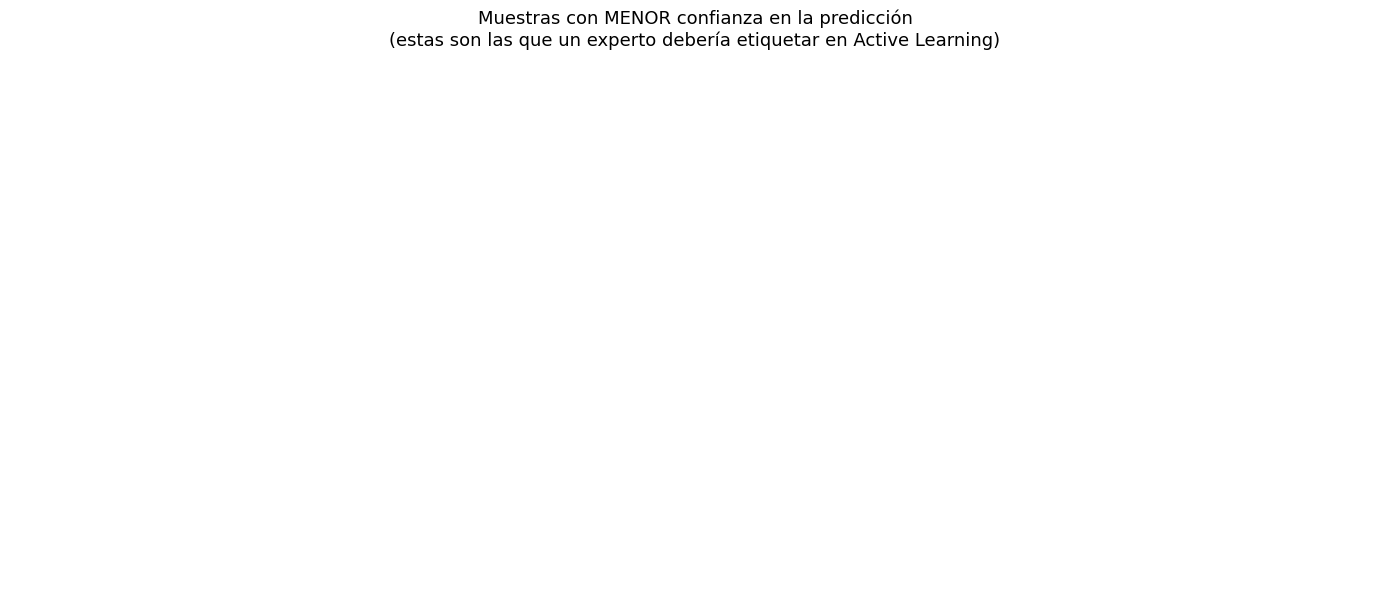

In [76]:
# Visualizar las imágenes más inciertas
X_lowest_confidence = X_train[:1000][sorted_ixs[:k_semi]]
X_lowest_orig = scaler.inverse_transform(X_lowest_confidence)

plt.figure(figsize=(14, 6))
for i, img_vec in enumerate(X_lowest_orig):
    plt.subplot(5, 10, i + 1)
    if not USE_REAL_DATASET:
        plt.imshow(img_vec.reshape(28, 28), cmap='binary', interpolation='bilinear')
    plt.axis('off')

plt.suptitle("Muestras con MENOR confianza en la predicción\n"
             "(estas son las que un experto debería etiquetar en Active Learning)",
             fontsize=13)
plt.tight_layout()
plt.show()

**CORREGIR ETIQUETAS DE LAS MUESTRAS INCIERTAS**
(en la práctica: un experto las etiqueta; aquí usamos las reales)

In [77]:
y_corrected = y_train[:1000][sorted_ixs[:k_semi]]  # etiquetas reales
print(f"Etiquetas corregidas (reales): {y_corrected}")

Etiquetas corregidas (reales): [11 18  5 21 16  4 11  4 18 11 18  2 13 21 11 11 18 21 14  4  4 14 18 18
 14 11  4  5  6 21  5  5  5 16  3  2 20 14 14 14 16  4 21  2  8  0  4  8
 11 21]


REENTRENAR CON LAS ETIQUETAS CORREGIDAS
**texto en negrita**

In [78]:
y_train_active = y_train_propagated[:1000].copy()
y_train_active[sorted_ixs[:k_semi]] = y_corrected  # reemplazamos con etiquetas reales

log_reg_active = LogisticRegression(
    multi_class='ovr', solver='lbfgs', max_iter=5000, random_state=42
)
log_reg_active.fit(X_train[:1000], y_train_active)
score_active = log_reg_active.score(X_test, y_test)

print(f"\n Resumen comparativo:")
print(f"   50 muestras aleatorias:       {score_random*100:.2f}%")
print(f"   50 muestras representativas:  {score_rep*100:.2f}%")
print(f"   1000 muestras propagadas:     {score_prop*100:.2f}%")
print(f"   1000 muestras + Active Learn: {score_active*100:.2f}%")
print(f"\n Mejora del Active Learning sobre propagación: +{(score_active - score_prop)*100:.2f}%")

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.



 Resumen comparativo:
   50 muestras aleatorias:       31.54%
   50 muestras representativas:  36.93%
   1000 muestras propagadas:     42.10%
   1000 muestras + Active Learn: 42.46%

 Mejora del Active Learning sobre propagación: +0.36%


**VISUALIZACIÓN FINAL — Comparación de todos los enfoques**

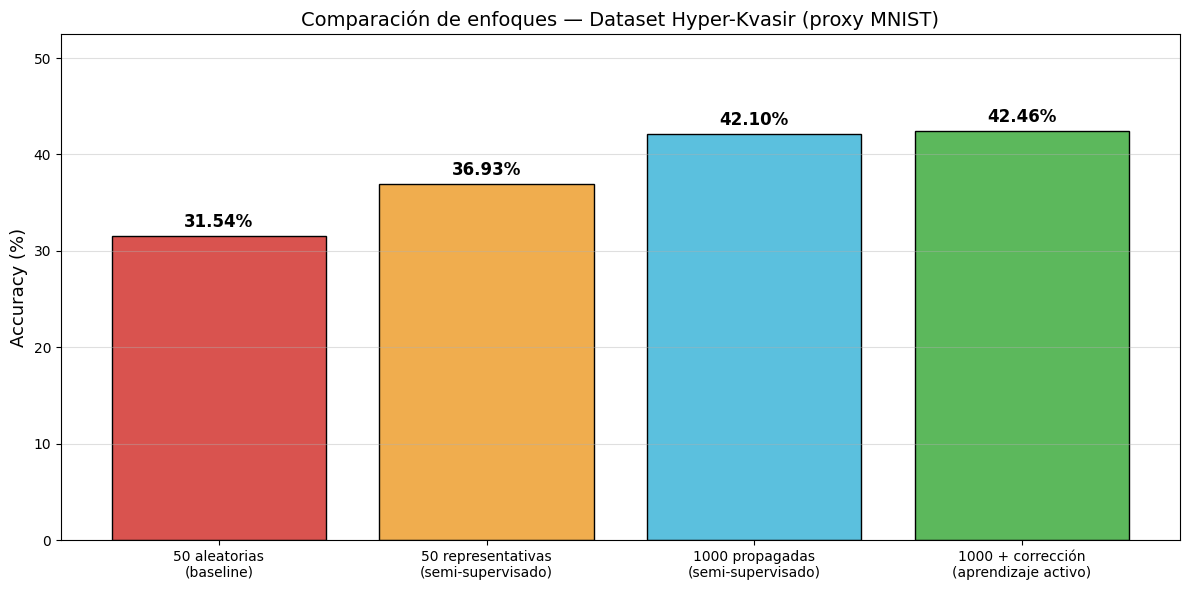


 Conclusión:
   → Las muestras REPRESENTATIVAS son más valiosas que las aleatorias.
   → El APRENDIZAJE ACTIVO mejora el modelo corrigiendo los errores más impactantes.
   → Ambas técnicas permiten entrenar buenos modelos con POCAS etiquetas manuales.


In [79]:
metodos = [
    "50 aleatorias\n(baseline)",
    "50 representativas\n(semi-supervisado)",
    "1000 propagadas\n(semi-supervisado)",
    "1000 + corrección\n(aprendizaje activo)"
]
scores = [score_random, score_rep, score_prop, score_active]
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']

plt.figure(figsize=(12, 6))
bars = plt.bar(metodos, [s * 100 for s in scores], color=colors, edgecolor='black')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f"{score*100:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("Comparación de enfoques — Dataset Hyper-Kvasir (proxy MNIST)", fontsize=14)
plt.ylim(0, min(105, max([s*100 for s in scores]) + 10))
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n Conclusión:")
print("   → Las muestras REPRESENTATIVAS son más valiosas que las aleatorias.")
print("   → El APRENDIZAJE ACTIVO mejora el modelo corrigiendo los errores más impactantes.")
print("   → Ambas técnicas permiten entrenar buenos modelos con POCAS etiquetas manuales.")